## 1. Setup & data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg

pd.set_option('display.precision', 2)
plt.rcParams['figure.dpi'] = 110


In [2]:
df = pd.read_csv('results\world_coord_comparison_persubject.csv')
df.head()


<>:1: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
<>:1: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
C:\Users\dylan\AppData\Local\Temp\ipykernel_5032\2227486987.py:1: SyntaxWarning: "\w" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\w"? A raw string is also an option.
  df = pd.read_csv('results\world_coord_comparison_persubject.csv')


,Task,Plane,Subject,OMC,MMC_2D,MMC_3D_world,err_2D,err_3D
0,Hip internal rotation,out-of-plane,P03,75.5,73.0,57.6,2.5,17.9
1,Hip internal rotation,out-of-plane,P04,69.0,86.4,60.3,17.4,8.7
2,Hip internal rotation,out-of-plane,P05,70.5,84.5,84.7,14.0,14.2
3,Hip internal rotation,out-of-plane,P06,55.8,49.0,34.6,6.9,21.2
4,Hip internal rotation,out-of-plane,P07,60.4,67.8,43.0,7.3,17.4


## 2. Scatter plots vs identity line

Points above the dashed `y = x` line mean MMC **over-estimates** the OMC angle;
points below mean it under-estimates.

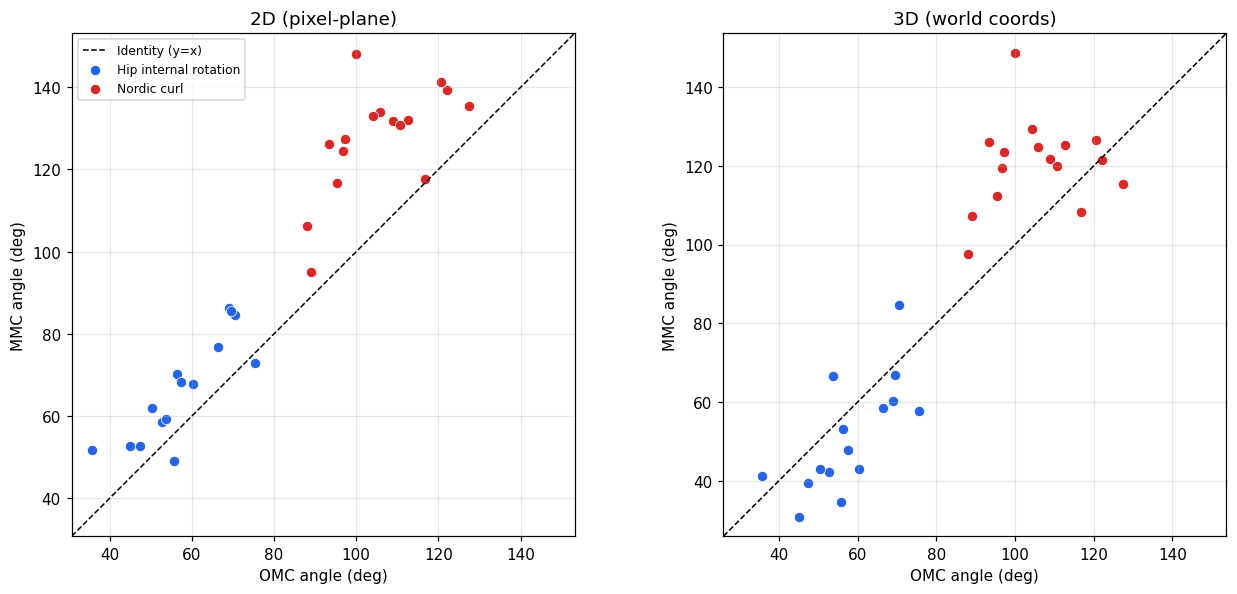

In [3]:
tasks = df['Task'].unique()
colors = {tasks[0]: '#2563eb', tasks[1]: '#dc2626'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, mmc_col, title in zip(axes, ['MMC_2D', 'MMC_3D_world'], ['2D (pixel-plane)', '3D (world coords)']):
    lims = [min(df['OMC'].min(), df[mmc_col].min()) - 5, max(df['OMC'].max(), df[mmc_col].max()) + 5]
    ax.plot(lims, lims, 'k--', lw=1, label='Identity (y=x)')
    for t in tasks:
        sub = df[df['Task'] == t]
        ax.scatter(sub['OMC'], sub[mmc_col], color=colors[t], label=t, s=45, edgecolor='white', linewidth=0.5)
    ax.set_xlabel('OMC angle (deg)')
    ax.set_ylabel('MMC angle (deg)')
    ax.set_title(title)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()


## 3. Bland-Altman plots

The proper way to assess **agreement** between two measurement methods
(correlation only tests linear association, not whether the values actually match).

- x-axis: mean of the two measurements
- y-axis: difference (MMC − OMC)
- solid line: mean bias
- dashed lines: 95% limits of agreement (bias ± 1.96 SD)

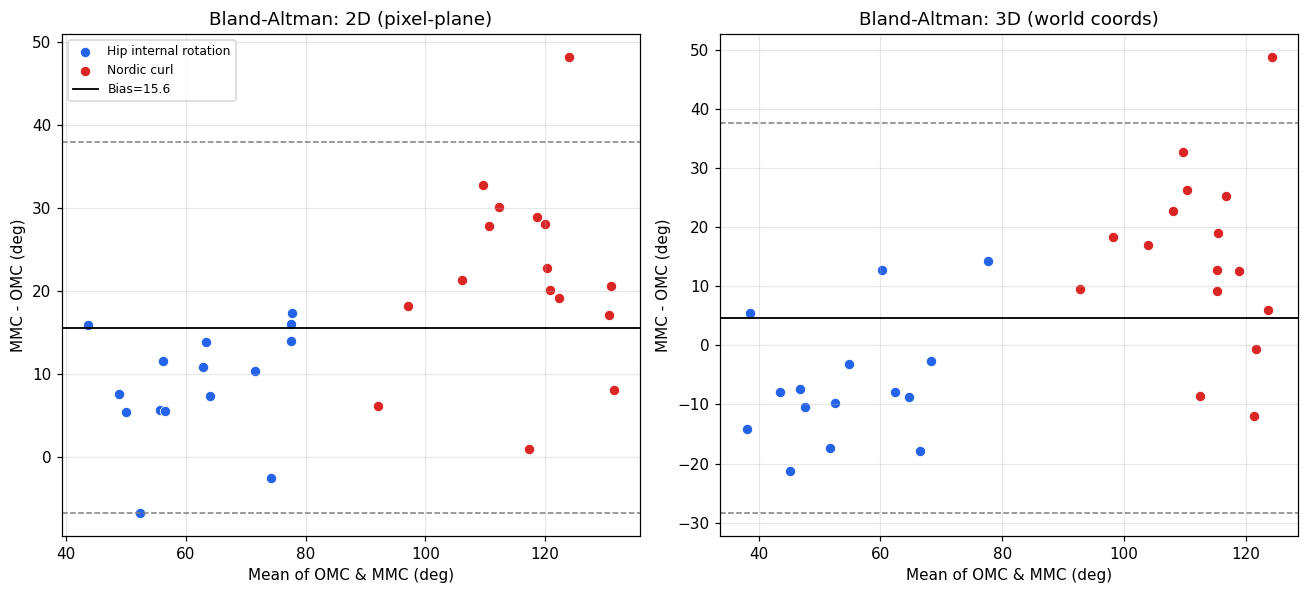

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, mmc_col, title in zip(axes, ['MMC_2D', 'MMC_3D_world'], ['2D (pixel-plane)', '3D (world coords)']):
    mean = (df['OMC'] + df[mmc_col]) / 2
    diff = df[mmc_col] - df['OMC']
    bias = diff.mean()
    sd = diff.std()
    for t in tasks:
        m = df['Task'] == t
        ax.scatter(mean[m], diff[m], color=colors[t], label=t, s=45, edgecolor='white', linewidth=0.5)
    ax.axhline(bias, color='k', lw=1.2, label=f'Bias={bias:.1f}')
    ax.axhline(bias + 1.96 * sd, color='gray', ls='--', lw=1)
    ax.axhline(bias - 1.96 * sd, color='gray', ls='--', lw=1)
    ax.set_xlabel('Mean of OMC & MMC (deg)')
    ax.set_ylabel('MMC - OMC (deg)')
    ax.set_title(f'Bland-Altman: {title}')
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


## 4. Error distribution by task & coordinate space

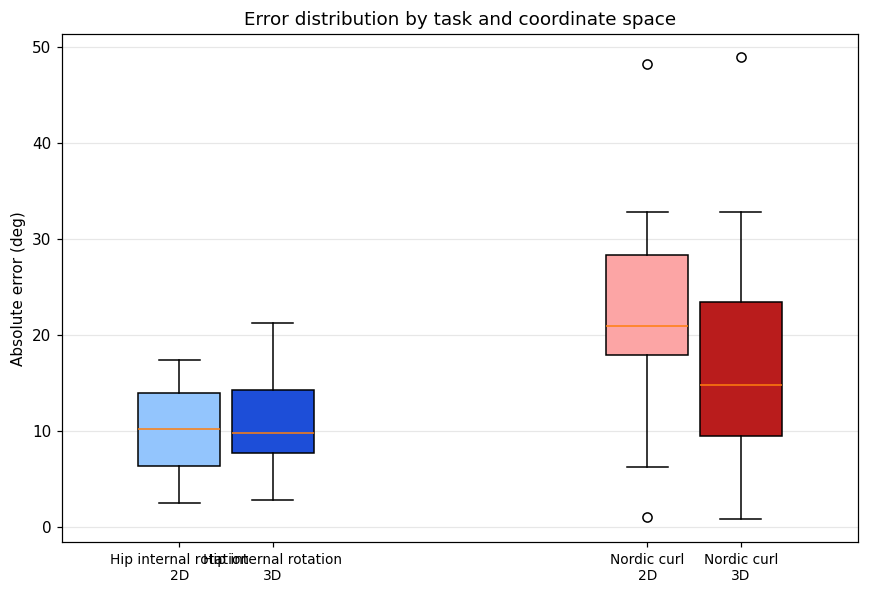

In [5]:
fig, ax = plt.subplots(figsize=(8, 5.5))
positions, data_box, labels = [], [], []
pos = 0
width = 0.35
for t in tasks:
    sub = df[df['Task'] == t]
    data_box.append(sub['err_2D'].values); positions.append(pos); labels.append(f'{t}\n2D')
    data_box.append(sub['err_3D'].values); positions.append(pos + width + 0.05); labels.append(f'{t}\n3D')
    pos += 2

bp = ax.boxplot(data_box, positions=positions, widths=width, patch_artist=True)
box_colors = ['#93c5fd', '#1d4ed8', '#fca5a5', '#b91c1c']
for patch, c in zip(bp['boxes'], box_colors):
    patch.set_facecolor(c)
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Absolute error (deg)')
ax.set_title('Error distribution by task and coordinate space')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## 5. Per-subject paired error (2D vs 3D)

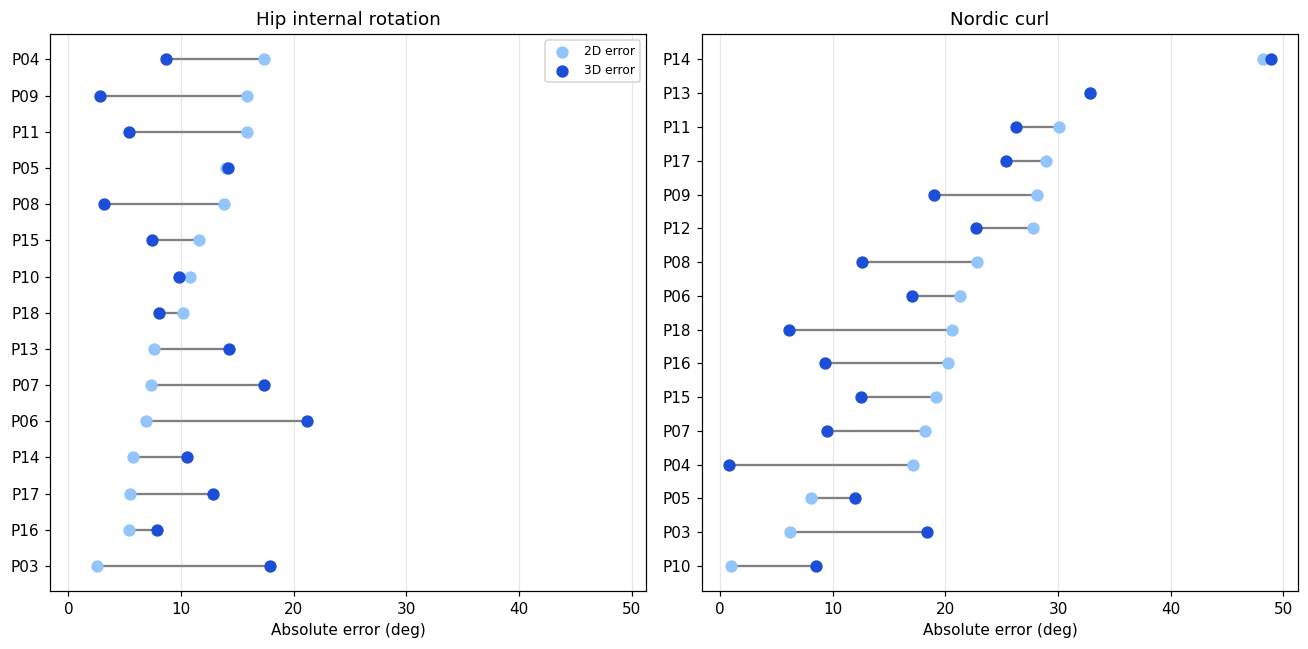

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True)
for ax, t in zip(axes, tasks):
    sub = df[df['Task'] == t].sort_values('err_2D')
    y = np.arange(len(sub))
    ax.hlines(y, sub['err_2D'], sub['err_3D'], color='gray', lw=1.5, zorder=1)
    ax.scatter(sub['err_2D'], y, color='#93c5fd', label='2D error', zorder=2, s=50)
    ax.scatter(sub['err_3D'], y, color='#1d4ed8', label='3D error', zorder=2, s=50)
    ax.set_yticks(y)
    ax.set_yticklabels(sub['Subject'])
    ax.set_xlabel('Absolute error (deg)')
    ax.set_title(t)
    ax.grid(alpha=0.3, axis='x')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


## 6. Summary statistics

- **Bias / SD** — mean and spread of the signed error
- **RMSE** — root-mean-square error (penalises large errors more)
- **Pearson r** — linear association only (not agreement)

In [7]:
def summarize(g):
    return pd.Series({
        'n': len(g),
        'mean_err_2D': g['err_2D'].mean(),
        'sd_err_2D': g['err_2D'].std(),
        'mean_err_3D': g['err_3D'].mean(),
        'sd_err_3D': g['err_3D'].std(),
        'RMSE_2D': np.sqrt((g['err_2D']**2).mean()),
        'RMSE_3D': np.sqrt((g['err_3D']**2).mean()),
        'r_2D': np.corrcoef(g['OMC'], g['MMC_2D'])[0, 1],
        'r_3D': np.corrcoef(g['OMC'], g['MMC_3D_world'])[0, 1],
    })

summary = df.groupby('Task').apply(summarize)
summary


,n,mean_err_2D,sd_err_2D,mean_err_3D,sd_err_3D,RMSE_2D,RMSE_3D,r_2D,r_3D
Task,,,,,,,,,
Hip internal rotation,15.0,10.03,4.60,10.77,5.44,10.98,11.98,0.85,0.69
Nordic curl,16.0,21.91,11.32,17.61,11.81,24.50,21.00,0.61,0.17
